In [2]:
import pandas as pd

In [3]:
from Descriptive import Descriptive

In [4]:
obj=Descriptive()

In [5]:
#pip install yfinance

In [6]:
from nsepy import get_history as gh
import datetime as dt
import yfinance as yf
stock_symbol = "RELIANCE.NS" #NSE stocks usually end with .NS
#dowload the stock data from NSE
stk_data=yf.download(stock_symbol, start="2024-05-01", end="2025-10-09")

[*********************100%***********************]  1 of 1 completed


In [7]:
stk_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 358 entries, 2024-05-02 to 2025-10-08
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, RELIANCE.NS)   358 non-null    float64
 1   (High, RELIANCE.NS)    358 non-null    float64
 2   (Low, RELIANCE.NS)     358 non-null    float64
 3   (Open, RELIANCE.NS)    358 non-null    float64
 4   (Volume, RELIANCE.NS)  358 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 16.8 KB


In [8]:
stk_data=stk_data[["Open","High","Low","Close"]]

In [9]:
stk_data

Price,Open,High,Low,Close
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,
2024-05-02,1454.460329,1459.721831,1446.679164,1449.075317
2024-05-03,1453.472210,1457.375095,1399.275803,1416.913086
2024-05-06,1418.395221,1422.841601,1401.103743,1402.610596
2024-05-07,1399.102859,1403.820987,1375.413559,1384.775635
2024-05-08,1380.848112,1415.875659,1380.848112,1401.647339
...,...,...,...,...
2025-10-01,1360.708629,1372.255218,1356.428371,1362.400757
2025-10-03,1356.926092,1365.287457,1350.655159,1357.125244


In [10]:
column="Close"

In [11]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1= Ms.fit_transform(stk_data[[column]])
print("Len:",data1.shape)

Len: (358, 1)


In [12]:
len(data1)

358

In [13]:
training_size = round(len(data1 ) * 0.80)
print(training_size)
X_train=data1[:training_size]
X_test=data1[training_size:]
print("X_train length:",X_train.shape)
print("X_test length:",X_test.shape)
y_train=data1[:training_size]
y_test=data1[training_size:]
print("y_train length:",y_train.shape)
print("y_test length:",y_test.shape)

286
X_train length: (286, 1)
X_test length: (72, 1)
y_train length: (286, 1)
y_test length: (72, 1)


In [14]:
from sklearn.metrics import mean_squared_error
import numpy as np

In [15]:
trends=['n','t','c','ct']
lags=[1,2,3,4]
from statsmodels.tsa.ar_model import AutoReg
for i in lags:
    #print(i)
   
    for td in trends:
        
        #print(td)
        #trendslist.append(td)
        model = AutoReg(X_train, lags=i,trend=td)
        model_fit = model.fit()
        # make prediction
        y_pred= model_fit.predict(len(X_train), len(data1)-1)
        #print(y_pred)
        #mse=mean_squared_error(y_test,y_pred,squared=False)
        from stockFunctions1 import rmsemape
        print("Lag={},Trend={}".format(i,td))
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        print("RMSE-Testset:", rmse)
        print("************")

Lag=1,Trend=n
RMSE-Testset: 0.09373519375449157
************
Lag=1,Trend=t
RMSE-Testset: 0.23137106073205677
************
Lag=1,Trend=c
RMSE-Testset: 0.08963931017517743
************
Lag=1,Trend=ct
RMSE-Testset: 0.12037326778044818
************
Lag=2,Trend=n
RMSE-Testset: 0.10400944135785685
************
Lag=2,Trend=t
RMSE-Testset: 0.23414876674208296
************
Lag=2,Trend=c
RMSE-Testset: 0.09600017263633749
************
Lag=2,Trend=ct
RMSE-Testset: 0.11168282473724897
************
Lag=3,Trend=n
RMSE-Testset: 0.10745504691009217
************
Lag=3,Trend=t
RMSE-Testset: 0.23521485038218773
************
Lag=3,Trend=c
RMSE-Testset: 0.09762697374113403
************
Lag=3,Trend=ct
RMSE-Testset: 0.09910232568741294
************
Lag=4,Trend=n
RMSE-Testset: 0.11252082374578079
************
Lag=4,Trend=t
RMSE-Testset: 0.2365627468716485
************
Lag=4,Trend=c
RMSE-Testset: 0.10033394086212859
************
Lag=4,Trend=ct
RMSE-Testset: 0.08880303597154625
************


In [16]:
len(y_pred)

72

In [17]:
i=1
td='ct'
model = AutoReg(X_train, lags=i,trend=td)
model_fit = model.fit()
# make prediction
y_pred= model_fit.predict(len(X_train), len(data1)-1)
#print(y_pred)
from sklearn.metrics import r2_score
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
from stockFunctions1 import rmsemape
print("Lag={},Trend={}".format(i,td))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)
print("************")
import warnings
warnings.filterwarnings("ignore")

Lag=1,Trend=ct
RMSE: 0.12037326778044818
************


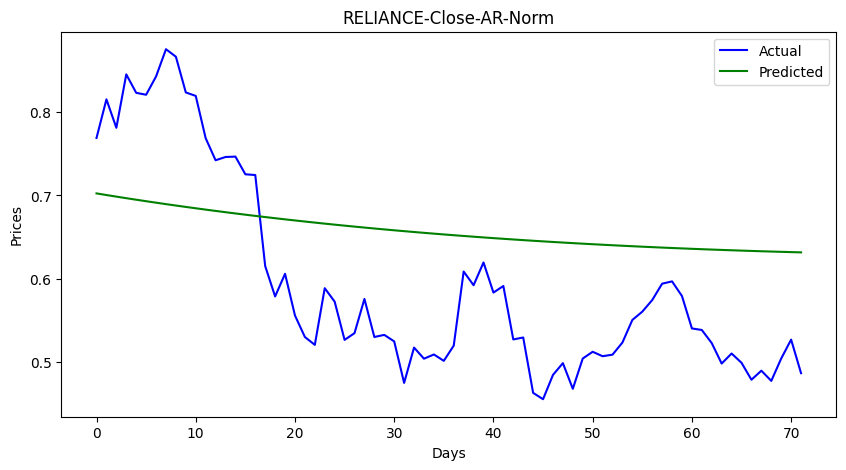

In [18]:
from stockFunctions1 import graph
graph(y_test,y_pred,"Actual","Predicted","RELIANCE-Close-AR-Norm","Days","Prices")

In [19]:
len(data1)

358

In [20]:
y_test

array([[0.76893822],
       [0.81529579],
       [0.78116164],
       [0.84527833],
       [0.8231373 ],
       [0.82083119],
       [0.84274164],
       [0.87549144],
       [0.86649646],
       [0.82359847],
       [0.81944685],
       [0.76870735],
       [0.74218412],
       [0.74610516],
       [0.74656632],
       [0.7253482 ],
       [0.72442558],
       [0.61510423],
       [0.57866397],
       [0.60587894],
       [0.55583119],
       [0.52999971],
       [0.52054356],
       [0.588581  ],
       [0.57243654],
       [0.52654012],
       [0.5346125 ],
       [0.57566554],
       [0.52999971],
       [0.53253669],
       [0.52469547],
       [0.47487801],
       [0.51731484],
       [0.50393822],
       [0.50901188],
       [0.50137086],
       [0.51966354],
       [0.60858119],
       [0.59214083],
       [0.61946457],
       [0.5833415 ],
       [0.59121452],
       [0.52707342],
       [0.52938918],
       [0.46293231],
       [0.455291  ],
       [0.48446706],
       [0.498

In [21]:
from stockFunctions1 import conversionSingle
aTestNormTable=conversionSingle(y_test,[column])

In [22]:
aTestNormTable

,Close
0,0.768938
1,0.815296
2,0.781162
3,0.845278
4,0.823137
...,...
67,0.489561
68,0.477289
69,0.504149
70,0.526842


In [23]:
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)

In [24]:
actual_stock_price_test_ori

array([[1482.49731445],
       [1502.4251709 ],
       [1487.75183105],
       [1515.31384277],
       [1505.79602051],
       [1504.8046875 ],
       [1514.22338867],
       [1528.30163574],
       [1524.43493652],
       [1505.9942627 ],
       [1504.20959473],
       [1482.39807129],
       [1470.99645996],
       [1472.68200684],
       [1472.88024902],
       [1463.75915527],
       [1463.36254883],
       [1416.36828613],
       [1400.70361328],
       [1412.40258789],
       [1390.88842773],
       [1379.78417969],
       [1375.71923828],
       [1404.9666748 ],
       [1398.02661133],
       [1378.29699707],
       [1381.76708984],
       [1399.41467285],
       [1379.78417969],
       [1380.87475586],
       [1377.50402832],
       [1356.08886719],
       [1374.33129883],
       [1368.58105469],
       [1370.76208496],
       [1367.47741699],
       [1375.34094238],
       [1413.56420898],
       [1406.49694824],
       [1418.24267578],
       [1402.71435547],
       [1406.098

In [25]:
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column])

In [26]:
actual_stock_price_test_oriA

,Close
0,1482.497314
1,1502.425171
2,1487.751831
3,1515.313843
4,1505.796021
...,...
67,1362.400757
68,1357.125244
69,1368.671875
70,1378.426758


In [27]:
from stockFunctions1 import conversionSingle
aTestNormTable=conversionSingle(y_test,[column])
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column])

In [28]:
from stockFunctions1 import conversionSingle
pTestNormTable=conversionSingle(y_pred,[column])
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,[column])

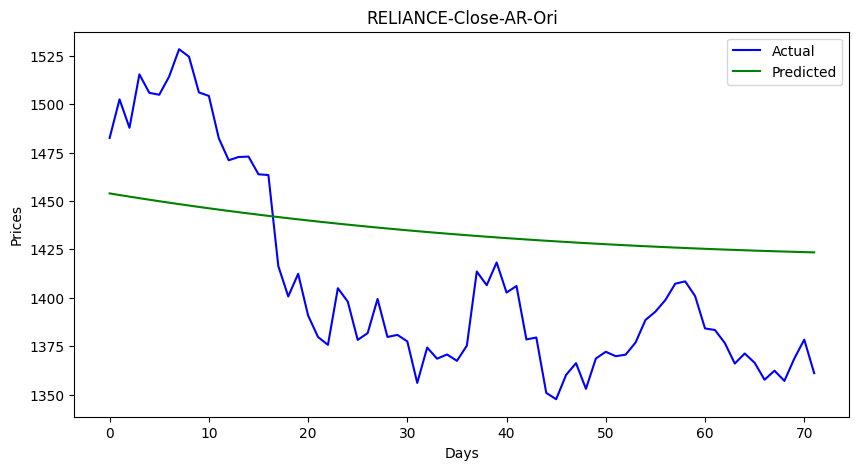

In [29]:
from stockFunctions1 import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","RELIANCE-Close-AR-Ori","Days","Prices")

In [30]:
import importlib
import stockFunctions1

importlib.reload(stockFunctions1)
from stockFunctions1 import rmsemape

In [31]:
from stockFunctions1 import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Testset: 51.74517930107427
MAPE-Testset: 0.03474933917280835


In [32]:
forecast=model_fit.predict(len(data1), len(data1)+3)

In [33]:
forecast

array([0.63128167, 0.63098849, 0.63070812, 0.63044039])

In [35]:
from stockFunctions1 import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [36]:
forecast_stock_price_test_oriF

,Closefore
0,1423.322524
1,1423.196495
2,1423.075974
3,1422.960881


In [37]:
forecast_stock_price_test_oriF.to_csv("CloseAR.csv",index=False)

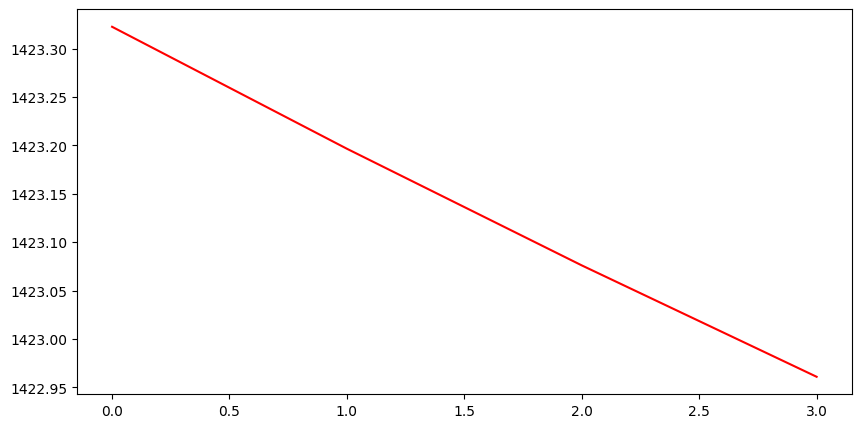

In [38]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(actual_stock_price_test_oriA[116:145], color = 'blue', label="Actual")
plt.plot(forecast_stock_price_test_oriF, color = 'red', label ="Predicted")